# HCP_4.3 — Phase dependence

Separate notebook for the phase–perturbation branch.

This notebook is intentionally separate from the energy/background-dependence notebooks so that:
- the energy analysis remains clean and easy to interpret
- the phase analysis can stay exploratory without changing the core dataframe pipeline

Main idea:
- compute **local phase** from the ROI time series
- compute **global phase** from the global phase of the Kuramoto order parameter
- relate phase to the **whole-brain perturbation outcome** for each stimulated ROI

This version keeps the coding structure and imports style of the attached 4.3 notebook, while making
the phase computations and profile plots much closer to the original 4.1 phase cells.

Notes:
- this notebook does **not** add save/export steps
- the histogram section is kept as an extra summary because it is useful


In [1]:
# ============================================================
# HCP_4.3_Phase_dependence
# Separate notebook for phase–perturbation analyses
# Continuation of the HCP ANN perturbation pipeline
# ============================================================

import os
import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import hilbert, detrend
from scipy.stats import pearsonr, chi2

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch

warnings.filterwarnings("ignore")


In [2]:
# Repository / environment setup
# ------------------------------------------------------------
repo_dir = Path.cwd().resolve().parent
results_dir = repo_dir / "Results"
processed_dir = results_dir / "processed"
ects_dir = results_dir / "ECts"

sys.path.insert(0, str(repo_dir))

from src import NPI


In [3]:
# Settings
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Baseline mode:
#   "current_state" -> use the last N columns from flattened ANN windows
#   "full_window"   -> use the full ANN input window (not recommended for phase here)
baseline_mode = "current_state"

# Optional preprocessing for Hilbert phase
DO_DETREND = True
DO_ZSCORE = False

# Histogram summary controls
use_histograms = True


In [4]:
# Helpers
# ------------------------------------------------------------
def discover_subject_ids(processed_dir, ects_dir):
    processed_ids = {p.name.replace("_inputs.npy", "") for p in processed_dir.glob("*_inputs.npy")}
    ect_ids = {p.name.replace("_ECt.npy", "") for p in ects_dir.glob("*_ECt.npy")}
    subject_ids = sorted(processed_ids & ect_ids)
    return subject_ids


def recover_state_matrix(X, n_regions, mode="current_state"):
    """
    Convert ANN inputs into a state matrix for phase extraction.

    Parameters
    ----------
    X : ndarray
        Either:
        - shape (T, S*N): flattened ANN windows
        - shape (T, N): already state-shaped
    n_regions : int
        Number of ROIs.
    mode : {"current_state", "full_window"}
        How to interpret flattened inputs.

    Returns
    -------
    X_state : ndarray
        State matrix used for the analysis.
    """
    X = np.asarray(X)

    if X.ndim != 2:
        raise ValueError(f"Expected 2D array, got shape {X.shape}")

    if X.shape[1] == n_regions:
        return X

    if X.shape[1] % n_regions != 0:
        raise ValueError(
            f"Input width {X.shape[1]} is not divisible by n_regions={n_regions}"
        )

    if mode == "current_state":
        return X[:, -n_regions:]

    if mode == "full_window":
        return X

    raise ValueError(f"Unknown mode: {mode}")


def hilbert_phase(x, do_detrend=True, zscore=False):
    """
    x: (T, N) real OR complex
    Returns:
      phi: (T, N) phase in radians
    """
    x = np.asarray(x)

    if np.iscomplexobj(x):
        return np.angle(x)

    if do_detrend:
        x = detrend(x, axis=0, type="linear")

    if zscore:
        x = (x - x.mean(axis=0, keepdims=True)) / (
            x.std(axis=0, ddof=1, keepdims=True) + 1e-12
        )

    analytic = hilbert(x, axis=0)
    return np.angle(analytic)


def circ_lin_corr(theta, x):
    """
    Circular-linear correlation between circular theta (radians) and linear x.
    Returns:
      rho in [0,1] and p-value (chi-square approx, df=2).
    """
    theta = np.asarray(theta).ravel()
    x = np.asarray(x).ravel()

    mask = np.isfinite(theta) & np.isfinite(x)
    theta = theta[mask]
    x = x[mask]

    n = len(x)
    if n < 5 or np.std(x) == 0:
        return np.nan, np.nan

    c = np.cos(theta)
    s = np.sin(theta)

    if np.std(c) == 0 or np.std(s) == 0:
        return np.nan, np.nan

    r_xc, _ = pearsonr(x, c)
    r_xs, _ = pearsonr(x, s)
    r_cs, _ = pearsonr(c, s)

    denom = (1 - r_cs**2)
    if denom <= 0:
        return np.nan, np.nan

    rho2 = (r_xc**2 + r_xs**2 - 2 * r_xc * r_xs * r_cs) / denom
    rho2 = np.clip(rho2, 0, 1)
    rho = np.sqrt(rho2)

    p = 1 - chi2.cdf(n * rho2, df=2)
    return rho, p


In [5]:
# Main phase analysis (close to the original 4.1 logic)
# ------------------------------------------------------------
subject_ids = discover_subject_ids(processed_dir, ects_dir)
print(f"Found {len(subject_ids)} subjects with both inputs and EC_t files.")

Xs = {}
ECts = {}

for sid in subject_ids:
    X = np.load(processed_dir / f"{sid}_inputs.npy")
    EC_t = np.load(ects_dir / f"{sid}_ECt.npy")

    M, N, N2 = EC_t.shape
    if N != N2:
        raise ValueError(f"EC_t must be square in the last two dims, got {EC_t.shape}")

    X_state = recover_state_matrix(X[:M], N, mode=baseline_mode)
    if X_state.shape[1] != N:
        raise ValueError(
            f"Phase analysis expects state-shaped data (T, N). "
            f"Got {X_state.shape}. Use baseline_mode='current_state'."
        )

    Xs[sid] = X_state
    ECts[sid] = EC_t

print(f"Prepared {len(Xs)} subjects for phase analysis.")


Found 100 subjects with both inputs and EC_t files.
Prepared 100 subjects for phase analysis.


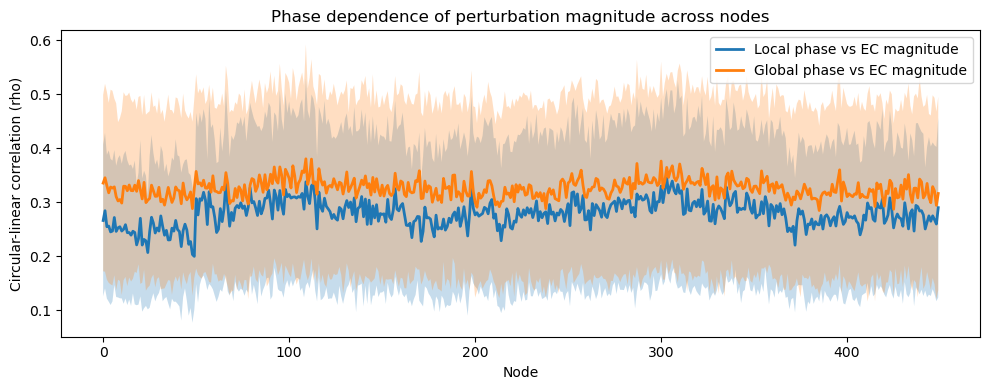

In [6]:
# Circular-linear phase vs perturbation correlations per node
# ------------------------------------------------------------
all_r_nodes_local  = []
all_p_nodes_local  = []
all_r_nodes_global = []
all_p_nodes_global = []

for sid in subject_ids:
    EC_t = ECts[sid]      # expected shape: (M, N, N)
    X    = Xs[sid]        # expected shape: (M, N)

    M, N = EC_t.shape[0], EC_t.shape[1]
    x_t = X[:M, :]        # shape: (M, N)

    # --- Phase over time ---
    phi = hilbert_phase(x_t, do_detrend=DO_DETREND, zscore=DO_ZSCORE)  # (M, N)

    # Global phase (Kuramoto order parameter phase)
    phi_global = np.angle(np.mean(np.exp(1j * phi), axis=1))           # (M,)

    r_nodes_local  = np.full(N, np.nan, dtype=float)
    p_nodes_local  = np.full(N, np.nan, dtype=float)
    r_nodes_global = np.full(N, np.nan, dtype=float)
    p_nodes_global = np.full(N, np.nan, dtype=float)

    for j in range(N):
        # EC magnitude for node j at time t (outgoing row energy)
        ec_j_t = np.sum(EC_t[:, j, :]**2, axis=1)  # (M,)

        # Local phase (node j) vs EC magnitude (node j)
        r_local, p_local = circ_lin_corr(phi[:, j], ec_j_t)

        # Global phase vs EC magnitude (node j)
        r_global, p_global = circ_lin_corr(phi_global, ec_j_t)

        r_nodes_local[j]  = r_local
        p_nodes_local[j]  = p_local
        r_nodes_global[j] = r_global
        p_nodes_global[j] = p_global

    all_r_nodes_local.append(r_nodes_local)
    all_p_nodes_local.append(p_nodes_local)
    all_r_nodes_global.append(r_nodes_global)
    all_p_nodes_global.append(p_nodes_global)

all_r_nodes_local  = np.vstack(all_r_nodes_local)   # (n_subj, N)
all_p_nodes_local  = np.vstack(all_p_nodes_local)
all_r_nodes_global = np.vstack(all_r_nodes_global)  # (n_subj, N)
all_p_nodes_global = np.vstack(all_p_nodes_global)

nodes = np.arange(all_r_nodes_local.shape[1])

mean_local = np.nanmean(all_r_nodes_local, axis=0)
std_local  = np.nanstd(all_r_nodes_local, axis=0, ddof=1)

mean_global = np.nanmean(all_r_nodes_global, axis=0)
std_global  = np.nanstd(all_r_nodes_global, axis=0, ddof=1)

plt.figure(figsize=(10, 4))
plt.plot(nodes, mean_local, linewidth=2, label='Local phase vs EC magnitude')
plt.fill_between(nodes, mean_local-std_local, mean_local+std_local, alpha=0.25)
plt.plot(nodes, mean_global, linewidth=2, label='Global phase vs EC magnitude')
plt.fill_between(nodes, mean_global-std_global, mean_global+std_global, alpha=0.25)
plt.xlabel('Node')
plt.ylabel('Circular-linear correlation (rho)')
plt.title('Phase dependence of perturbation magnitude across nodes')
plt.legend()
plt.tight_layout()
plt.show()


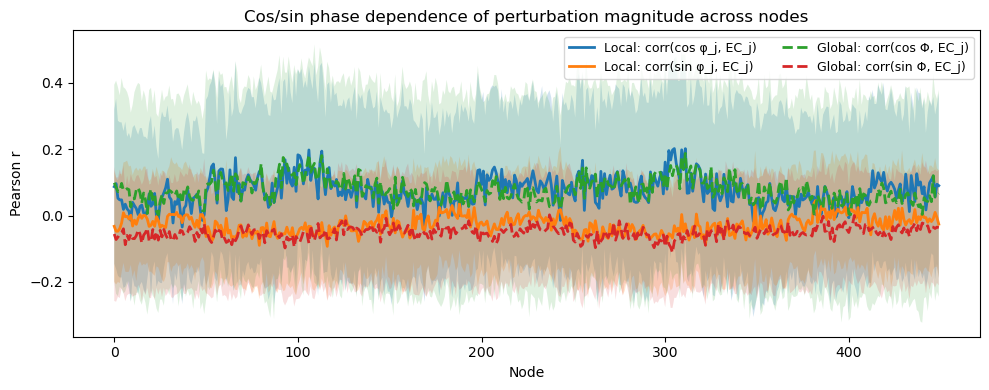

In [7]:
# Cos/sin(phase) vs perturbation correlations per node
# ------------------------------------------------------------
all_r_cos_local   = []
all_p_cos_local   = []
all_r_sin_local   = []
all_p_sin_local   = []

all_r_cos_global  = []
all_p_cos_global  = []
all_r_sin_global  = []
all_p_sin_global  = []

for sid in subject_ids:
    EC_t = ECts[sid]   # expected (M, N, N)
    X    = Xs[sid]     # expected (M, N)

    M, N = EC_t.shape[0], EC_t.shape[1]
    x_t = X[:M, :]

    # Phase per node over time
    phi = hilbert_phase(x_t, do_detrend=DO_DETREND, zscore=False)  # (M, N)

    # Global phase (Kuramoto order parameter phase)
    phi_global = np.angle(np.mean(np.exp(1j * phi), axis=1))  # (M,)

    cg = np.cos(phi_global)
    sg = np.sin(phi_global)

    r_cos_local  = np.full(N, np.nan)
    p_cos_local  = np.full(N, np.nan)
    r_sin_local  = np.full(N, np.nan)
    p_sin_local  = np.full(N, np.nan)

    r_cos_global = np.full(N, np.nan)
    p_cos_global = np.full(N, np.nan)
    r_sin_global = np.full(N, np.nan)
    p_sin_global = np.full(N, np.nan)

    for j in range(N):
        # EC magnitude for node j at each time t (outgoing row energy)
        y = np.sum(EC_t[:, j, :]**2, axis=1)  # (M,)

        c = np.cos(phi[:, j])
        s = np.sin(phi[:, j])

        # Local: correlate cos/sin(node phase) with EC magnitude of node j
        r_cos_local[j], p_cos_local[j] = pearsonr(c, y)
        r_sin_local[j], p_sin_local[j] = pearsonr(s, y)

        # Global: correlate cos/sin(global phase) with EC magnitude of node j
        r_cos_global[j], p_cos_global[j] = pearsonr(cg, y)
        r_sin_global[j], p_sin_global[j] = pearsonr(sg, y)

    all_r_cos_local.append(r_cos_local)
    all_p_cos_local.append(p_cos_local)
    all_r_sin_local.append(r_sin_local)
    all_p_sin_local.append(p_sin_local)
    all_r_cos_global.append(r_cos_global)
    all_p_cos_global.append(p_cos_global)
    all_r_sin_global.append(r_sin_global)
    all_p_sin_global.append(p_sin_global)

all_r_cos_local  = np.vstack(all_r_cos_local)
all_p_cos_local  = np.vstack(all_p_cos_local)
all_r_sin_local  = np.vstack(all_r_sin_local)
all_p_sin_local  = np.vstack(all_p_sin_local)

all_r_cos_global = np.vstack(all_r_cos_global)
all_p_cos_global = np.vstack(all_p_cos_global)
all_r_sin_global = np.vstack(all_r_sin_global)
all_p_sin_global = np.vstack(all_p_sin_global)

nodes = np.arange(all_r_cos_local.shape[1])

mean_cos_local = np.nanmean(all_r_cos_local, axis=0)
std_cos_local  = np.nanstd(all_r_cos_local, axis=0, ddof=1)

mean_sin_local = np.nanmean(all_r_sin_local, axis=0)
std_sin_local  = np.nanstd(all_r_sin_local, axis=0, ddof=1)

mean_cos_global = np.nanmean(all_r_cos_global, axis=0)
std_cos_global  = np.nanstd(all_r_cos_global, axis=0, ddof=1)

mean_sin_global = np.nanmean(all_r_sin_global, axis=0)
std_sin_global  = np.nanstd(all_r_sin_global, axis=0, ddof=1)

plt.figure(figsize=(10, 4))

# Local cos
plt.plot(nodes, mean_cos_local, linewidth=2, label='Local: corr(cos φ_j, EC_j)')
plt.fill_between(nodes, mean_cos_local-std_cos_local, mean_cos_local+std_cos_local, alpha=0.20)

# Local sin
plt.plot(nodes, mean_sin_local, linewidth=2, label='Local: corr(sin φ_j, EC_j)')
plt.fill_between(nodes, mean_sin_local-std_sin_local, mean_sin_local+std_sin_local, alpha=0.20)

# Global cos
plt.plot(nodes, mean_cos_global, linewidth=2, linestyle='--', label='Global: corr(cos Φ, EC_j)')
plt.fill_between(nodes, mean_cos_global-std_cos_global, mean_cos_global+std_cos_global, alpha=0.15)

# Global sin
plt.plot(nodes, mean_sin_global, linewidth=2, linestyle='--', label='Global: corr(sin Φ, EC_j)')
plt.fill_between(nodes, mean_sin_global-std_sin_global, mean_sin_global+std_sin_global, alpha=0.15)

plt.xlabel('Node')
plt.ylabel('Pearson r')
plt.title('Cos/sin phase dependence of perturbation magnitude across nodes')
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


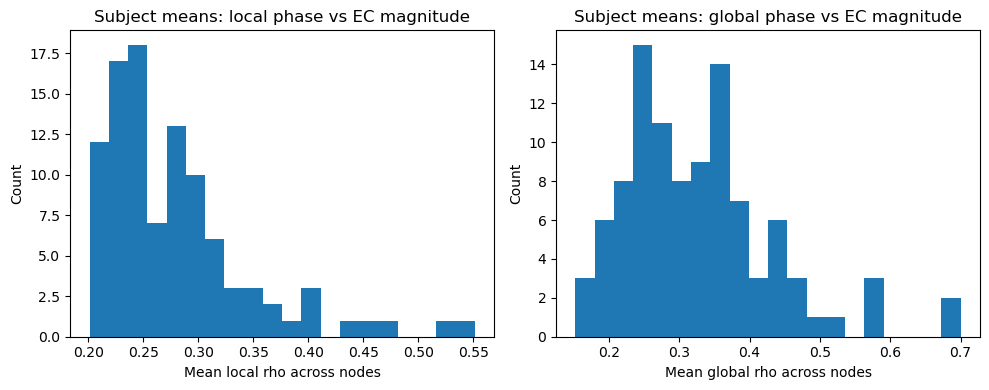

In [8]:
# Histogram summaries (kept as an extra section)
# ------------------------------------------------------------
if use_histograms:
    subject_mean_local = np.nanmean(all_r_nodes_local, axis=1)
    subject_mean_global = np.nanmean(all_r_nodes_global, axis=1)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.hist(subject_mean_local[~np.isnan(subject_mean_local)], bins=20)
    plt.xlabel('Mean local rho across nodes')
    plt.ylabel('Count')
    plt.title('Subject means: local phase vs EC magnitude')

    plt.subplot(1, 2, 2)
    plt.hist(subject_mean_global[~np.isnan(subject_mean_global)], bins=20)
    plt.xlabel('Mean global rho across nodes')
    plt.ylabel('Count')
    plt.title('Subject means: global phase vs EC magnitude')

    plt.tight_layout()
    plt.show()
